![header](../figures/logos_partenaires._cmems_se.jpg)

# Benchmark DUACS sea surface height maps

<div style="text-align: right"><i> 2023-04-27 DUACS_SSH_BENCHMARK_DEMO </i></div>

***
**Authors:**  CLS & Datlas <br>
**Copyright:** 2023 CLS & Datlas <br>
**License:** MIT

<div class="alert alert-block alert-success">
<h1><center>Benchmark of DUACS sea surface height maps</center></h1>
<h5> The notebook aims to evaluate the sea surface height maps produced by the DUACS system. </h5>
    <h5> These maps are equivalent to the SEALEVEL_GLO_PHY_L4_MY_008_047 product distributed by the Copernicus Marine Service, except that a nadir altimeter (SARAL/Altika, SEALEVEL_GLO_PHY_L3_MY_008_062 product) has been excluded from the mapping. </h5>
        <h5> We provide below a demonstration of the validation of these maps against the independent SSH data from the Saral/AltiKa altimeter distributed by CMEMS </h5>
</div>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Cell" and select "Run All Above Selected Cell".<br>
***


<div class="alert alert-danger" role="alert">

<h3>Learning outcomes</h3>

At the end of this notebook you will know:
<ul>
  <li>How you can evaluated sea surface height maps with independent alongtrack data: statistical and spectral analysis</li>
</ul>
    
</div>

In [60]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [61]:
from glob import glob
import numpy as np
import os

In [4]:
pip install hvplot

  Using cached hvplot-0.11.2-py3-none-any.whl.metadata (15 kB)
Using cached hvplot-0.11.2-py3-none-any.whl (161 kB)
Note: you may need to restart the kernel to use updated packages.


In [8]:
uv pip install --dry-run 'numpy<2.1' numba

/Odyssey/private/d21botvy/miniconda3/envs/forecast/bin/python: No module named uv
Note: you may need to restart the kernel to use updated packages.


In [68]:
import sys
sys.path.append('..')
from src.mod_plot import *
from src.mod_stat import *
from src.mod_spectral import *
from src.mod_interp import *
from src.mod_filter import *

In [4]:
import logging
logger = logging.getLogger()
logger.setLevel(logging.INFO)

<div class="alert alert-info" role="alert">

<h2>0. Parameters</h2>

</div>

In [5]:
time_min = '2023-01-01'                                        # time min for analysis
time_max = '2023-12-31'                                        # time max for analysis
output_dir = '../results'                                      # output directory path
os.system(f'mkdir -p {output_dir}')
method_name = '4DVARNET_SSH_not_SLA'
stat_output_filename = f'{output_dir}/stat_ssh.nc'  # output statistical analysis filename
lambda_min = 65.                                               # minimun spatial scale in kilometer to consider on the filtered signal
lambda_max = 500.                                              # maximum spatial scale in kilometer to consider on the filtered signal
psd_output_filename = f'{output_dir}/psd_ssh.nc'    # output spectral analysis filename
segment_lenght = 1000.                                         # spectral parameer: along-track segment lenght in kilometer to consider in the spectral analysis

<div class="alert alert-info" role="alert">

<h2>1. Input files</h2>

</div>

## Sea Surface Height from Saral/AltiKa

In [77]:
import glob

In [80]:
%%time
time_min = '2023-01-15'                                        # time min for analysis
time_max = '2023-12-16'

list_of_file = sorted(glob.glob('/Odyssey/public/altimetry_traces/processed_2023_global_4/dl/ref/**/**/*2024*/2023/**/*.nc'))
#sorted(glob('../data/independent_alongtrack/alg/2019/*.nc'))
ds_alg = xr.open_mfdataset(list_of_file)#, combine='nested', concat_dim='time')
ds_alg = ds_alg.rename(longitude="lon", latitude="lat").pipe(\
            lambda d: d.where(\
                (d.time.load() >= pd.to_datetime(time_min))\
                & (d.time <= pd.to_datetime(time_max)),\
                drop=True,\
            )\
        )\
        .assign(ssh=lambda d: d.sla_filtered + d.mdt - d.lwe)\
        .sortby("time")[["ssh", "sla_filtered", "sla_unfiltered", "mdt", "lwe"]]

#ds_alg = xr.open_dataset('/Odyssey/public/altimetry_traces/processed_2023_global_4/concat/concatenated_input.nc')

#ds_alg = ds_alg.where((ds_alg.time >= np.datetime64(time_min)) & (ds_alg.time <=  np.datetime64(time_max)), drop=True)
#ds_alg = ds_alg.sortby('time')
ds_alg

CPU times: user 48.1 s, sys: 3.22 s, total: 51.4 s
Wall time: 52.2 s


<xarray.Dataset> Size: 859MB
Dimensions:         (time: 13416630)
Coordinates:
  * time            (time) datetime64[ns] 107MB 2023-01-15T23:47:29.547174912...
    lat             (time) float64 107MB -64.98 -64.92 -64.87 ... -63.32 -66.34
    lon             (time) float64 107MB 110.1 110.1 110.0 ... 254.4 254.2 251.3
Data variables:
    ssh             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_filtered    (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    sla_unfiltered  (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    mdt             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
    lwe             (time) float64 107MB dask.array<chunksize=(41176,), meta=np.ndarray>
Attributes: (12/44)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Swath
    comment:                         Sea surface height measured by altimeter...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    summary:                         SSALTO/DUACS Delayed-Time Level-3 sea su...
    time_coverage_duration:          P23H11M4.556364S
    time_coverage_end:               2023-01-01T23:27:36Z
    time_coverage_resolution:        P1S
    time_coverage_start:             2023-01-01T00:16:31Z
    title:                           DT Altika Drifting Phase Global Ocean Al...

In [81]:
ds_alg = ds_alg.rename({'lon' : 'longitude'})
ds_alg = ds_alg.rename({'lat' : 'latitude'})

## Sea Surface Height maps to evaluate

In [39]:
%%time
list_of_maps = "/Odyssey/public/glorys/rec/glorys4_global_1patch10y/nrt_2023_global_4/test_data_14.nc"
#sorted(glob('../data/maps/DUACS_global_allsat-alg/*.nc'))
ds_maps = xr.open_mfdataset(list_of_maps, combine='nested', concat_dim='time')
ds_maps = ds_maps.sel(time=slice(time_min, time_max))
ds_maps

CPU times: user 14.4 ms, sys: 2.19 ms, total: 16.6 ms
Wall time: 23.5 ms


<xarray.Dataset> Size: 1GB
Dimensions:  (time: 336, lat: 680, lon: 1440)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2023-01-15 2023-01-16 ... 2023-12-16
  * lat      (lat) float64 5kB -80.0 -79.75 -79.5 -79.25 ... 89.25 89.5 89.75
  * lon      (lon) float64 12kB -180.0 -179.8 -179.5 ... 179.2 179.5 179.8
Data variables:
    out      (time, lat, lon) float32 1GB dask.array<chunksize=(336, 680, 1440), meta=np.ndarray>

In [40]:
ds_maps = ds_maps.rename({'out': 'sla'})
ds_maps = ds_maps.rename({'lon': 'longitude'})
ds_maps = ds_maps.rename({'lat': 'latitude'})

## Very important manipulation in order to make DC21 notebooks work ! 

In [41]:
ds_maps.coords['longitude'] = (ds_maps.coords['longitude'] + 360) % 360
ds_maps = ds_maps.sortby(['longitude'])
#ds_maps = ds_maps.sortby('time')
ds_maps.latitude.attrs['units'] = 'degrees_north'
ds_maps.longitude.attrs['units'] = 'degrees_east'
#ds_maps = ds_maps.sortby('time')

## SLA becomes SSH in our version of evaluation workflow: add MDT as variable to the ds_maps dataset

In [42]:
mdt_ds = xr.open_dataset("/Odyssey/public/duacs/1993_2013/duacs_global_0.25deg_1993_2013_mdt.nc")
mdt_3d = np.repeat(mdt_ds.mdt.values[np.newaxis, :, :], 336, axis=0) # 337 days with 15 days missing in the beginning of the year (confirm Pierre)
ds_maps['mdt'] = (['time', 'latitude', 'longitude'], mdt_3d[:,40:,:]) # 40: only for 4dvarnet

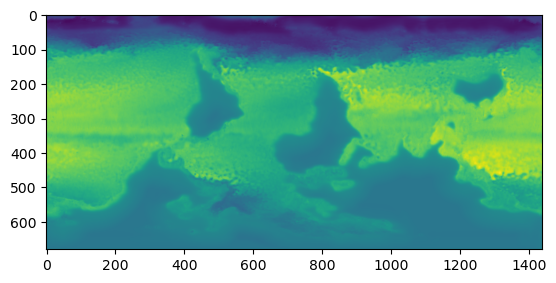

In [36]:
plt.imshow(ds_maps.sla[-1])

<div class="alert alert-info" role="alert">

<h2>2. Statistical & Spectral Analysis </h2>

</div>

## 2.1 Interpolate sea surface height maps onto along-track positions

### 2.1.1 Additionally, interpolate mdt from ds_maps onto along-track positions -> changed /src/mod_interp.py

In [37]:
np.max(ds_maps.sla.values)

np.float32(2.0288086)

In [48]:
ds_alg.time

<xarray.DataArray 'time' (time: 77314378)> Size: 619MB
array(['2023-01-15T00:00:00.012556288', '2023-01-15T00:00:00.193603328',
       '2023-01-15T00:00:01.012556032', ..., '2023-12-15T23:59:59.055095808',
       '2023-12-15T23:59:59.350410752', '2023-12-15T23:59:59.539692032'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 619MB 2023-01-15T00:00:00.012556288 ... 20...
    lon      (time) float64 619MB 150.7 -36.17 150.7 ... -27.27 85.3 163.8
    lat      (time) float64 619MB 4.123 35.68 4.064 ... -17.23 -34.83 57.52

In [82]:
ds_interp = run_interpolation(ds_maps, ds_alg)
ds_interp = ds_interp.dropna('time')
ds_interp

2025-01-23 16:34:38 INFO     fetch data from 2023-01-15 00:00:00 to 2023-02-01 00:00:00
2025-01-23 16:34:40 INFO     fetch data from 2023-01-15 00:00:00 to 2023-02-01 00:00:00
2025-01-23 16:34:41 INFO     fetch data from 2023-01-31 00:00:00 to 2023-03-01 00:00:00
2025-01-23 16:34:43 INFO     fetch data from 2023-01-31 00:00:00 to 2023-03-01 00:00:00
2025-01-23 16:34:43 INFO     fetch data from 2023-02-28 00:00:00 to 2023-04-01 00:00:00
2025-01-23 16:34:45 INFO     fetch data from 2023-02-28 00:00:00 to 2023-04-01 00:00:00
2025-01-23 16:34:46 INFO     fetch data from 2023-03-31 00:00:00 to 2023-05-01 00:00:00
2025-01-23 16:34:48 INFO     fetch data from 2023-03-31 00:00:00 to 2023-05-01 00:00:00
2025-01-23 16:34:49 INFO     fetch data from 2023-04-30 00:00:00 to 2023-06-01 00:00:00
2025-01-23 16:34:51 INFO     fetch data from 2023-04-30 00:00:00 to 2023-06-01 00:00:00
2025-01-23 16:34:52 INFO     fetch data from 2023-05-31 00:00:00 to 2023-07-01 00:00:00
2025-01-23 16:34:54 INFO     fet

<xarray.Dataset> Size: 1GB
Dimensions:            (time: 13101633)
Coordinates:
  * time               (time) datetime64[ns] 105MB 2023-01-15T23:47:29.547174...
Data variables:
    ssh                (time) float64 105MB -1.295 -1.301 ... -0.768 -0.895
    sla_filtered       (time) float64 105MB 0.034 0.033 0.033 ... 0.009 0.165
    sla_unfiltered     (time) float64 105MB 0.036 0.032 0.04 ... -0.006 0.168
    mdt                (time) float64 105MB -1.313 -1.318 ... -0.756 -1.056
    lwe                (time) float64 105MB 0.016 0.016 0.016 ... 0.021 0.004
    latitude           (time) float64 105MB -64.98 -64.92 ... -63.32 -66.34
    longitude          (time) float64 105MB 110.1 110.1 110.0 ... 254.2 251.3
    msla_interpolated  (time) float64 105MB -1.223 -1.223 ... -0.7446 -0.8857
    mmdt_interpolated  (time) float64 105MB -1.329 -1.33 ... -0.7508 -1.025

In [83]:
ds_interp.msla_interpolated[0]

<xarray.DataArray 'msla_interpolated' ()> Size: 8B
array(-1.22308944)
Coordinates:
    time     datetime64[ns] 8B 2023-01-15T23:47:29.547174912

### 2.1.2 Now replace SLA from altimeters to SSH: SSH_altimeters = SLA_altimeters + MDT_interpolated

In [84]:
ds_interp['sla_unfiltered_old'] = ds_interp['sla_unfiltered'] # to keep original SLA
ds_interp['sla_filtered_old'] = ds_interp['sla_filtered'] # to keep original SLA
ds_interp['sla_unfiltered'] = ds_interp['sla_unfiltered_old'] + ds_interp['mmdt_interpolated'] # new variable is SSH, but is still called sla ! 
ds_interp['sla_filtered'] = ds_interp['sla_filtered_old'] + ds_interp['mmdt_interpolated'] # new variable is SSH, but is still called sla ! 

In [85]:
compute_median_dx(ds_interp)

np.float64(6.9877745333057675)

In [72]:
compute_median_from_multiple_satellites(ds_alg)

np.float64(6.686871279914913)

## 2.2 Compute grid boxes statistics & statistics by regime (coastal, offshore low variability, offshore high variability)

Once the maps have been interpolated to the position of the along-track, it is possible to calculate different statistics on the time series SLA_alongtrack and SLA_maps. 

We propose below the following statistics: error variance maps (static by 1°x1° box), explained variance maps, temporal evolution of global error variance and explained variance. 

These statistics are also applied to the filtered signals focusing on the 65-500km scale range. A bandpass filter is applied before calculating the scores.  

In [86]:
compute_stat_scores(ds_interp, lambda_min, lambda_max, stat_output_filename,method_name)

2025-01-23 16:35:58 INFO     Compute mapping error all scales


2025-01-23 16:35:58 INFO     Compute mapping error for scales between 65.0 and 500.0 km


Total RMSE= 0.04989820545250539 m
Total RMSE score= 0.9378626546101742 m


2025-01-23 16:36:44 INFO     Compute binning statistics
2025-01-23 16:36:51 INFO     Compute statistics by oceanic regime
2025-01-23 16:37:07 INFO     Stat file saved as: ../results/stat_ssh.nc


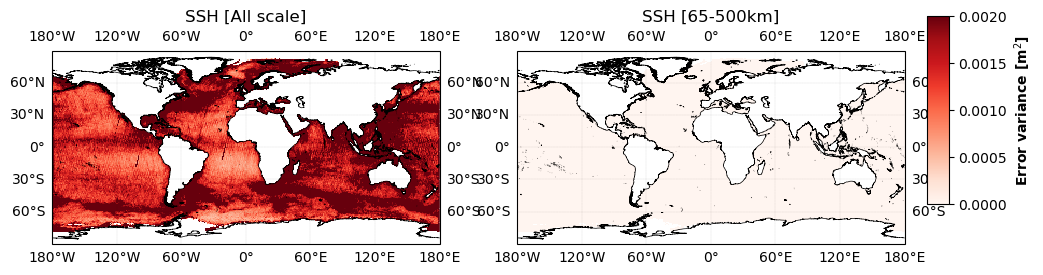

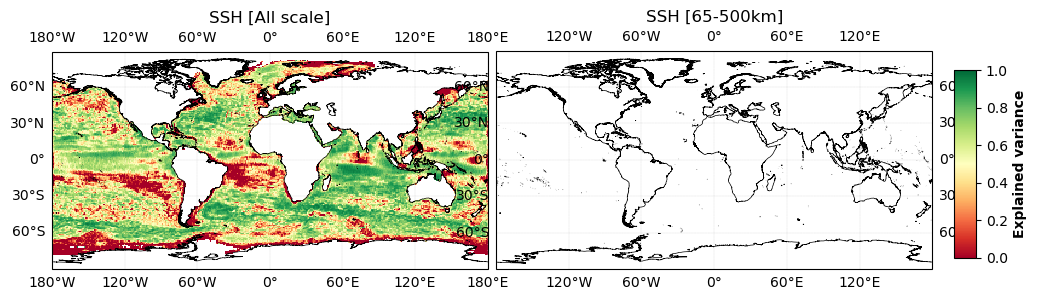

In [58]:
# Plot gridded stats
# Hvplot
# plot_stat_score_map(stat_output_filename)
# Matplotlib
plot_stat_score_map_png(stat_output_filename)

In [ ]:
plot_stat_score_timeseries(stat_output_filename)

:Layout
   .Overlay.I  :Overlay
      .Curve.All_scale :Curve   [time]   (timeserie_variance_mapping_err)
      .Curve.Filtered  :Curve   [time]   (timeserie_variance_mapping_err)
   .Overlay.II :Overlay
      .Curve.All_scale :Curve   [time]   (explained_variance_score)
      .Curve.Filtered  :Curve   [time]   (explained_variance_score)

### 2.2.1 I modified /src/mod_stat.py in order to add the computation of nRMSE score for mappieng err; I also modified /src/mod_plot.py in order to include RMSE and nRMSE score to the table

In [73]:
plot_stat_by_regimes(stat_output_filename)

,mapping_err_var [m²],mapping_err_rms,mapping_err_nrms_score,sla_unfiltered_var [m²],sla_unfiltered_rms,sla_unfiltered_nrms_score,mapping_err_filtered_var [m²],mapping_err_filtered_rms,mapping_err_filtered_nrms_score,sla_filtered_var [m²],sla_filtered_rms,sla_filtered_nrms_score,var_score_allscale,var_score_filtered
coastal,0.003177,0.056456,0.930053,0.350614,0.833904,0.930053,0.0,0.0,0.930053,0.0,0.0,0.930053,0.990938,NaN
offshore_highvar,0.007232,0.085310,0.894302,0.317674,0.775850,0.894302,0.0,0.0,0.894302,0.0,0.0,0.894302,0.977235,NaN
offshore_lowvar,0.001815,0.042977,0.946753,0.506859,0.800771,0.946753,0.0,0.0,0.946753,0.0,0.0,0.946753,0.996418,NaN
equatorial_band,0.002017,0.045722,0.943351,0.058755,0.881253,0.943351,0.0,0.0,0.943351,0.0,0.0,0.943351,0.965678,NaN
arctic,0.002404,0.049313,0.938902,0.015463,0.263911,0.938902,0.0,0.0,0.938902,0.0,0.0,0.938902,0.844521,NaN
antarctic,0.003786,0.062872,0.922103,0.004222,1.197752,0.922103,0.0,0.0,0.922103,0.0,0.0,0.922103,0.103240,NaN


## 2.3 Compute Spectral scores

In [ ]:
compute_psd_scores_v2(ds_interp, psd_output_filename, lenght_scale=segment_lenght,method_name=method_name)

2024-09-11 20:21:28 INFO     Segment computation...
2024-09-11 20:21:40 INFO     Spectral analysis...
2024-09-11 20:36:31 INFO     Saving ouput...
2024-09-11 20:36:40 INFO     PSD file saved as: ../results/psd_sla_duacs_geos.nc


Averaged effective resolution: 218.18302355039634 km


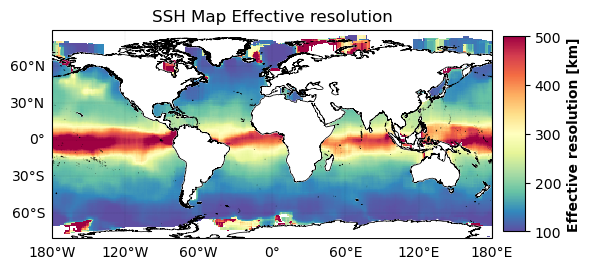

In [ ]:
# Plot effective resolution
# Hvplot
# plot_effective_resolution(psd_output_filename)
# Matplotlib
plot_effective_resolution_png(psd_output_filename)

In [ ]:
plot_psd_scores(psd_output_filename)

:Layout
   .DynamicMap.I   :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_alongtrack   :Curve   [wavelenght]   (psd_ref)
         .Curve.NOISE_alongtrack :Curve   [wavelenght]   (noise)
         .Curve.PSD_map          :Curve   [wavelenght]   (psd_study)
         .Curve.PSD_err          :Curve   [wavelenght]   (psd_diff)
   .DynamicMap.II  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.PSD_map_over_PSD_ref :Curve   [wavelenght]   (psd_ratio)
         .Curve.I                    :Curve   [wavelenght]   (coherence)
   .DynamicMap.III :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (psd_score)
         .Curve.II :Curve   [wavelenght]   (coherence)
   .DynamicMap.IV  :DynamicMap   [lon,lat]
      :Overlay
         .Curve.I  :Curve   [wavelenght]   (coherence)
         .Curve.II :Curve   [wavelenght]   (coherence)

The interactive plot above allows you to explore the spectral metrics by latitude / longitude box